In [19]:
import qcodes as qc
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import scienceplots

In [20]:
plt.style.use(['science','no-latex'])

In [21]:
db_path = r"C:\Users\emile\Thesis\Data_processing\Marcus_old_sample\Marcus_old_sample.db"

qc.initialise_or_create_database_at(db_path)

experiment = qc.load_or_create_experiment(experiment_name="resonant fluorescence ", sample_name="Marcus_old_sample")

In [22]:
def load_and_extract(run_id):
    dataset = qc.load_by_run_spec(experiment_name="resonant fluorescence ", captured_run_id=run_id)
    data = dataset.get_parameter_data()
    countrate = data["countrate"]["countrate"]
    #voltage = data["countrate"]["keysight_ch2_source_voltage"]
    wavelength = data["countrate"]["santec_wavelength"]
    return countrate, wavelength

In [23]:
#experiment

In [24]:
dataset = qc.load_by_run_spec(experiment_name="resonant fluorescence ", captured_run_id=263)

In [25]:
data = dataset
#data.snapshot["station"]["instruments"]["santec"]

In [26]:
countrate, wavelength = load_and_extract(263) # 232, 233, 259, 258, 162

sigma_y = np.sqrt(countrate) / np.max(countrate)

countrate = countrate / np.max(countrate)

In [27]:
# Convert to frequency

c = 299792458 #m/s
wavelength_m = wavelength* 1e-9  

frequency = c / wavelength_m


In [28]:
# Fit Lorentzian 
def lorentzian(x, A, x0, gamma):
    return A / (1 + ((x-x0) / (gamma/2))**2)

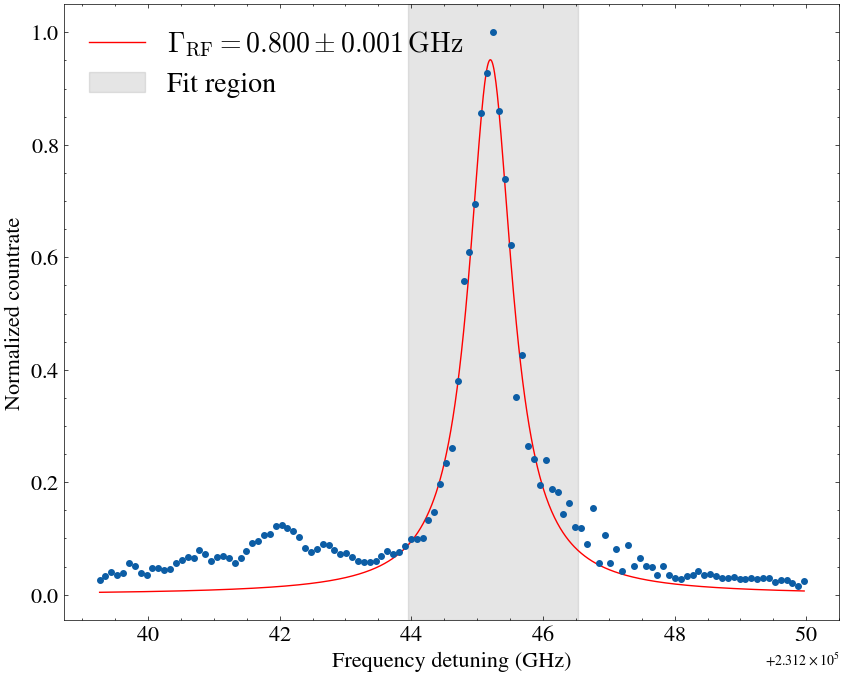

A = 0.9512812462113105
x0 = 231245201013957.9
Gamma (GHz) = 0.8000527946620042


In [29]:
def fit_and_plot(frequency, countrate, sigma_y, save_filename):
    A_guess = np.max(countrate) - np.min(countrate)
    x0_guess = frequency[np.argmax(countrate)]
    gamma_guess = (np.max(frequency) - np.min(frequency)) / 10
    C_guess = np.min(countrate)

    p0 = [A_guess, x0_guess, gamma_guess] # C_guess
    idx_peak = np.argmax(countrate)
    x0_guess = frequency[idx_peak]
    window = 0.12 * (max(frequency) - min(frequency))
    mask = np.abs(frequency - x0_guess) < window
    freq_fit = frequency[mask]
    count_fit = countrate[mask]
    sigma_fit = sigma_y[mask]


    params, covariance = curve_fit(
    lorentzian,
    freq_fit,
    count_fit,
    p0=p0,
    sigma=sigma_fit,
    absolute_sigma=True)

    A_fit, x0_fit, gamma_fit = params # C_fit
    
    perr = np.sqrt(np.diag(covariance))
    gamma_err = perr[2] * 10**(-9)
    
    gamma_GHz = gamma_fit * 10**(-9)


    # Chi2
    y_fit = lorentzian(freq_fit, *params)
    chi2 = np.sum((count_fit - y_fit)**2 / sigma_fit**2)
    dof = len(count_fit) - len(params)
    chi2_red = chi2 / dof

    x_fit = np.linspace(min(frequency), max(frequency), 1000)
    y_fit = lorentzian(x_fit, *params)
    
    plt.figure(figsize = (10,8))
    plt.errorbar(frequency/1e9, countrate, yerr=None, fmt='o', markersize=4)
    plt.plot(x_fit/1e9, y_fit, 'r-', label = fr"$\Gamma_{{\mathrm{{RF}}}} = {gamma_GHz:.3f} \pm {gamma_err:.3f}\,\mathrm{{GHz}}$")
    plt.axvspan((x0_guess - window)/1e9, (x0_guess + window)/1e9,
            color='gray', alpha=0.2, label='Fit region')
    plt.xlabel("Frequency detuning (GHz)", fontsize = 16)
    plt.ylabel("Normalized countrate", fontsize = 16)
    plt.legend(prop = {"size": 20})
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    plt.savefig(f"plots/{save_filename}.png", dpi = 300)
    plt.show()

    print(f"A = {A_fit}")
    print(f"x0 = {x0_fit}")
    print(f"Gamma (GHz) = {gamma_GHz}")
    #print(f"C = {C_fit}")
    return A_fit, x0_fit, gamma_GHz # , C_fit
A_fit, x0_fit, gamma_fit = fit_and_plot(frequency, countrate, sigma_y, "RF_fit") # C_fit

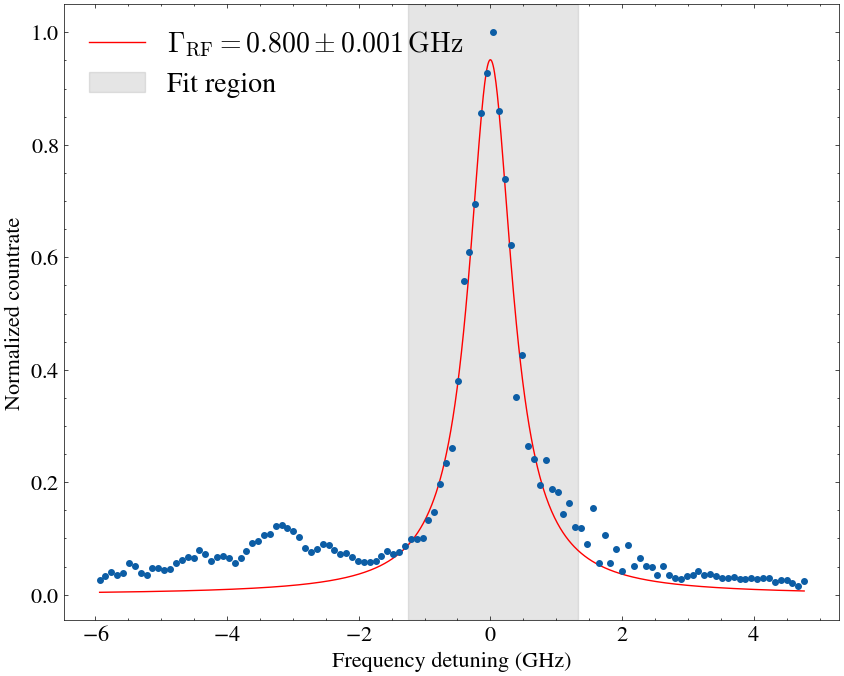

A = 0.9512832971664399
x0 = 48848.83490021173
Gamma (GHz) = 0.8000501427162994


In [30]:
# Convert wavelength into frequency 

detuned_x_axis = frequency - x0_fit

deA_fit, x0_fit, gamma_fit = fit_and_plot(detuned_x_axis, countrate, sigma_y, "RF_fit_detuned")

In [31]:
def lifetime_bound_from_Gamma(gamma_fit, S): # In ps
    return 1 / (gamma_fit*2*np.pi)   *( np.sqrt(1 + S) * 10**3)

lifetime_bound_from_Gamma(gamma_fit, S = 0)

198.93121017582553

The above is a bound on the lifetime, since it includes pure dephasing. Now the power saturation also plays a role, increasing it increases the bound on the lifetime. 

We can also try to use the the Gamma_deph from the g(2) fit to calculate a Gamma_lifetime (homogenous linewidth)

In [32]:
Gamma_deph = 0.56/(2*np.pi)

Gamma_lifetime = gamma_fit - 2*Gamma_deph
print(Gamma_lifetime*2*np.pi) 

3.906863301721983


In [33]:
tau = 1/(Gamma_lifetime*2*np.pi)
print(tau*1e3)

255.95981296792274


We can also try a model with a gaussian included to fit the side peak better

In [40]:
def model(x, A_lor, x0_lor, gamma,
               A_g, x0_g, sigma_g,
               C):
    lor = A_lor / (1 + ((x-x0_lor) / (gamma/2))**2)
    gauss = A_g * np.exp(-(x - x0_g)**2 / (2*sigma_g**2))
    return lor + gauss + C


def fit_and_plot(frequency, countrate, sigma_y, save_filename):

    A_lor_guess = np.max(countrate) - np.min(countrate)
    x0_lor_guess = frequency[np.argmax(countrate)]
    gamma_guess = (np.max(frequency) - np.min(frequency)) / 20

    A_g_guess = A_lor_guess / 4
    x0_g_guess = frequency[np.argmin(frequency)] + 0.25*(np.max(frequency)-np.min(frequency))
    sigma_g_guess = (np.max(frequency) - np.min(frequency)) / 10

    C_guess = np.min(countrate)

    p0 = [A_lor_guess, x0_lor_guess, gamma_guess,
          A_g_guess, x0_g_guess, sigma_g_guess,
          C_guess]

    params, covariance = curve_fit(
        model,
        frequency,
        countrate,
        p0=p0,
        sigma=sigma_y,
        absolute_sigma=True,
        maxfev=10000
    )

    (A_lor, x0_lor, gamma,
     A_g, x0_g, sigma_g,
     C) = params

    perr = np.sqrt(np.diag(covariance))
    gamma_err = perr[2] * 1e-9
    gamma_GHz = gamma * 1e-9

    y_fit_data = model(frequency, *params)
    chi2 = np.sum((countrate - y_fit_data)**2 / sigma_y**2)
    dof = len(countrate) - len(params)
    chi2_red = chi2 / dof
    #print("chi2_red:", chi2_red)

    x_fit = np.linspace(min(frequency), max(frequency), 1000)
    y_fit = model(x_fit, *params)

    y_guess = model(x_fit, *p0)
    plt.figure(figsize=(8,6))
    plt.errorbar(frequency/1e9, countrate, yerr=None, fmt='o', markersize=3)

    #plt.plot(x_fit/1e9, y_guess, 'k--', label="Initial guess")

    plt.plot(
        x_fit/1e9,
        y_fit,
        'r-',
        label=fr"$\Gamma_{{\mathrm{{RF}}}} = {gamma_GHz:.3f} \pm {gamma_err:.3f}\,\mathrm{{GHz}}$" # \pm {gamma_err:.3f}\,\mathrm{{GHz}}
    )
    
    plt.xlabel("Frequency detuning (GHz)", fontsize=18)
    plt.ylabel("Normalized countrate", fontsize=18)
    plt.legend(prop={"size": 16})
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.savefig(f"plots/{save_filename}.png", dpi=300)
    plt.show()

    #print(f"A_lor = {A_lor}")
    #print(f"x0_lor = {x0_lor}")
    #print(f"Gamma (GHz) = {gamma_GHz}")
    #print(f"A_gauss = {A_g}")
    #print(f"x0_gauss = {x0_g}")
    #print(f"C = {C}")
    return A_lor, x0_lor, gamma_GHz

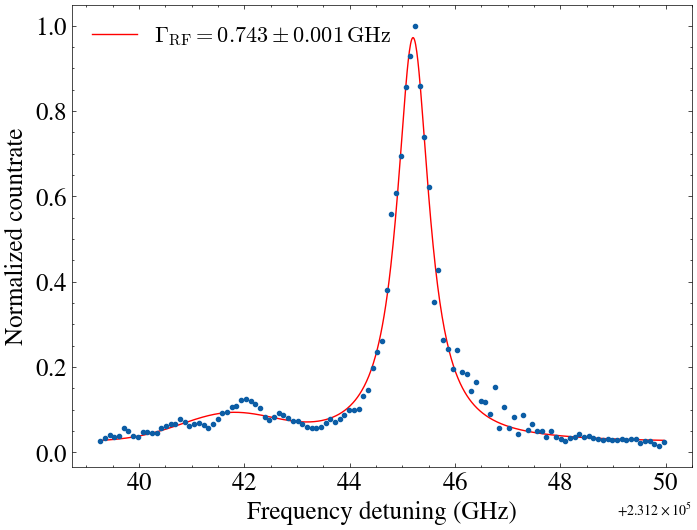

In [41]:
A_fit, x0_fit, gamma_fit = fit_and_plot(frequency, countrate, sigma_y, "RF_fit_with_gauss") 

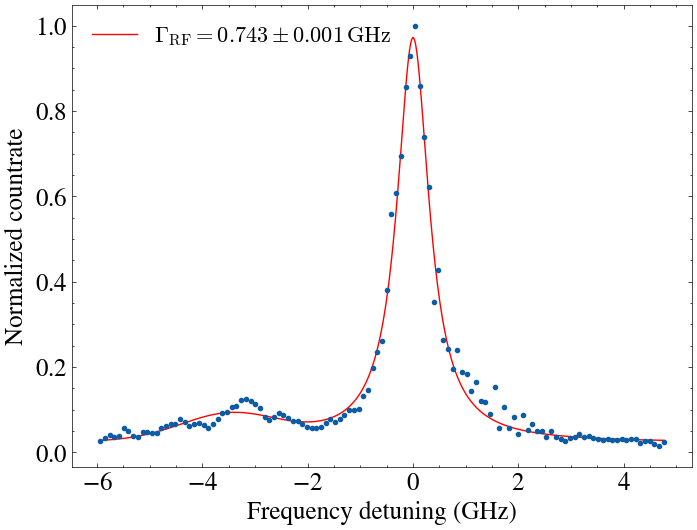

In [42]:
detuned_x_axis = frequency - x0_fit

deA_fit, x0_fit, gamma_fit = fit_and_plot(detuned_x_axis, countrate, sigma_y, "RF_fit_with_gauss_detuned")